# Etapa 4 — Teste da tese de compactos no Centro

Este notebook testa explicitamente a hipótese de que apartamentos compactos (studio/1 quarto) no Centro seriam a aposta mais eficiente para a Seazone.

Regras definidas antes do resultado:

- compacto residencial = apartamento com 0 ou 1 quarto;
- Airbnb principal = anúncios com 14+ datas válidas;
- ranking apenas com 20+ anúncios em cada fonte necessária;
- preços são anunciados, não receita nem transação realizada;
- studios e unidades de 1 quarto são exibidos separadamente;
- ausência de studios comparáveis no Centro implica evidência insuficiente para esse componente;
- retorno nesta etapa é bruto e indicativo; custos completos entram na Etapa 5.


In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
plt.style.use('seaborn-v0_8-whitegrid')


def encontrar_raiz(inicio=None):
    caminho = Path(inicio or Path.cwd()).resolve()
    for candidato in (caminho, *caminho.parents):
        if (candidato / 'data').is_dir() and (candidato / 'ROADMAP.md').is_file():
            return candidato
    raise FileNotFoundError('Raiz do projeto não encontrada.')


def sha256(caminho, tamanho_bloco=1024 * 1024):
    resumo = hashlib.sha256()
    with caminho.open('rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(tamanho_bloco), b''):
            resumo.update(bloco)
    return resumo.hexdigest().upper()


def converter_booleano(serie):
    if pd.api.types.is_bool_dtype(serie.dtype):
        return serie.astype('boolean')
    return serie.astype('string').str.strip().str.lower().map(
        {'true': True, 'false': False, '1': True, '0': False}
    ).astype('boolean')


RAIZ = encontrar_raiz()
DADOS = RAIZ / 'data'
METRICAS = RAIZ / 'outputs' / 'metricas'
AUDITORIA = RAIZ / 'outputs' / 'auditoria'
SAIDAS = RAIZ / 'outputs' / 'tese'
SAIDAS.mkdir(parents=True, exist_ok=True)

HASHES_DADOS = {
    'Details_Itapema.csv': '7A28A35811B5B01CA046D06E0AF80180E43D07AF6923FC03B76DF99AC01050C9',
    'Hosts_ids_Itapema.csv': 'B2E5AA3E0BD30A3FA63643ABC4BC3142C78BE165855BBD6C4D077D6BDE308EA9',
    'Mesh_Ids_Data_Itapema.csv': '7C9DAA0D37FE5C8FA10E6EFA53CB9E6F66E28880E165A62D3E1F9C74585ADF1E',
    'Price_AV_Itapema.csv': 'B0B5C8C07011DAF5C91F2FB9E7BA735026F0AE4542745481376140A714DD813B',
    'VivaReal_Itapema.csv': 'C720320AE6BCD34982323A2D6EEC6D5F5F18E316B3A3DAE0A37F03638E32A631',
}
hashes_antes = {p.name: sha256(p) for p in DADOS.glob('*.csv')}
assert hashes_antes == HASHES_DADOS
print(f'Raiz: {RAIZ}')
print(f'Saídas: {SAIDAS}')

Raiz: C:\Users\rewel\Documents\jt2026-Antonio-Rewelli-Santos
Saídas: C:\Users\rewel\Documents\jt2026-Antonio-Rewelli-Santos\outputs\tese


In [2]:
airbnb = pd.read_csv(
    METRICAS / 'metricas_por_anuncio.csv', dtype={'airbnb_listing_id': 'string'}, low_memory=False
)
vendas = pd.read_csv(AUDITORIA / 'vivareal_listings.csv', low_memory=False)

for coluna in ['amostra_elegivel_7_datas', 'amostra_elegivel_14_datas', 'amostra_elegivel_30_datas']:
    airbnb[coluna] = converter_booleano(airbnb[coluna]).fillna(False)
vendas['flag_preco_venda_invalido'] = converter_booleano(vendas['flag_preco_venda_invalido']).fillna(False)

assert airbnb['airbnb_listing_id'].is_unique
assert vendas['listing_id'].is_unique
assert len(airbnb) == 4441
assert len(vendas) == 8293

vendas_validas = vendas.loc[
    vendas['listing_type'].eq('apartamento')
    & ~vendas['flag_preco_venda_invalido']
    & vendas['sale_price'].gt(0)
    & vendas['usable_area'].gt(0)
].copy()
vendas_validas['preco_m2_anunciado'] = vendas_validas['sale_price'] / vendas_validas['usable_area']
vendas_validas['condominio_positivo'] = vendas_validas['monthly_condo_fee'].where(
    vendas_validas['monthly_condo_fee'].gt(0)
)
vendas_validas['iptu_positivo'] = vendas_validas['yearly_iptu'].where(
    vendas_validas['yearly_iptu'].gt(0)
)

SEGMENTOS = {
    'centro_studio': {
        'rotulo': 'Centro | studio',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('centro') & d['number_of_bedrooms'].eq(0),
        'vendas': lambda d: d['suburb_key'].eq('centro') & d['bedrooms'].eq(0),
    },
    'centro_1q': {
        'rotulo': 'Centro | 1 quarto',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('centro') & d['number_of_bedrooms'].eq(1),
        'vendas': lambda d: d['suburb_key'].eq('centro') & d['bedrooms'].eq(1),
    },
    'meiapraia_studio': {
        'rotulo': 'Meia Praia | studio',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('meiapraia') & d['number_of_bedrooms'].eq(0),
        'vendas': lambda d: d['suburb_key'].eq('meiapraia') & d['bedrooms'].eq(0),
    },
    'meiapraia_1q': {
        'rotulo': 'Meia Praia | 1 quarto',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('meiapraia') & d['number_of_bedrooms'].eq(1),
        'vendas': lambda d: d['suburb_key'].eq('meiapraia') & d['bedrooms'].eq(1),
    },
    'morretes_1q': {
        'rotulo': 'Morretes | 1 quarto',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('morretes') & d['number_of_bedrooms'].eq(1),
        'vendas': lambda d: d['suburb_key'].eq('morretes') & d['bedrooms'].eq(1),
    },
    'outros_compactos': {
        'rotulo': 'Outros bairros | studio/1 quarto',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & ~d['suburb_key'].eq('centro') & d['number_of_bedrooms'].le(1),
        'vendas': lambda d: ~d['suburb_key'].eq('centro') & d['bedrooms'].le(1),
    },
    'centro_2q': {
        'rotulo': 'Centro | 2 quartos',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('centro') & d['number_of_bedrooms'].eq(2),
        'vendas': lambda d: d['suburb_key'].eq('centro') & d['bedrooms'].eq(2),
    },
    'centro_3q': {
        'rotulo': 'Centro | 3 quartos',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('centro') & d['number_of_bedrooms'].eq(3),
        'vendas': lambda d: d['suburb_key'].eq('centro') & d['bedrooms'].eq(3),
    },
    'centro_4mais': {
        'rotulo': 'Centro | 4+ quartos',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['suburb_key'].eq('centro') & d['number_of_bedrooms'].ge(4),
        'vendas': lambda d: d['suburb_key'].eq('centro') & d['bedrooms'].ge(4),
    },
    'perfil_vencedor_etapa3': {
        'rotulo': 'Itapema | 4+ quartos e 7+ hóspedes',
        'airbnb': lambda d: d['listing_type'].eq('apartamento') & d['number_of_bedrooms'].ge(4) & d['number_of_guests'].ge(7),
        'vendas': lambda d: d['bedrooms'].ge(4),
    },
}

MINIMO = 20
OCUPACOES = {'conservador': 0.40, 'base': 0.55, 'otimista': 0.70}
PERIODO_AIRBNB = '2025-01-07 a 2025-04-20'
DATA_VIVAREAL = '2025-01-11'


def status_amostra(n):
    if n >= 20:
        return 'ranqueavel'
    if n >= 10:
        return 'exploratorio'
    return 'nao_ranqueavel'


display(pd.DataFrame([{
    'airbnb_total': len(airbnb),
    'airbnb_elegiveis_14': int(airbnb['amostra_elegivel_14_datas'].sum()),
    'vendas_apartamentos_validos': len(vendas_validas),
    'studios_centro_airbnb_elegiveis': int((SEGMENTOS['centro_studio']['airbnb'](airbnb) & airbnb['amostra_elegivel_14_datas']).sum()),
    'studios_centro_vivareal': int(SEGMENTOS['centro_studio']['vendas'](vendas_validas).sum()),
}]))

,airbnb_total,airbnb_elegiveis_14,vendas_apartamentos_validos,studios_centro_airbnb_elegiveis,studios_centro_vivareal
0,4441,959,7497,0,0


In [3]:
def resumir_airbnb(flag='amostra_elegivel_14_datas', filtrar_extremos=False):
    trabalho = airbnb.loc[airbnb[flag]].copy()
    if filtrar_extremos and len(trabalho):
        p1, p99 = trabalho['diaria_mediana_anunciada'].quantile([0.01, 0.99])
        trabalho = trabalho.loc[trabalho['diaria_mediana_anunciada'].between(p1, p99)].copy()
    linhas = []
    for chave, definicao in SEGMENTOS.items():
        grupo = trabalho.loc[definicao['airbnb'](trabalho)].copy()
        diaria = grupo['diaria_mediana_anunciada']
        premio = np.where(
            grupo['diaria_mediana_dia_util'].gt(0) & grupo['diaria_mediana_fim_semana'].notna(),
            (grupo['diaria_mediana_fim_semana'] / grupo['diaria_mediana_dia_util'] - 1) * 100,
            np.nan,
        )
        linha = {
            'segmento': chave,
            'rotulo': definicao['rotulo'],
            'anuncios_airbnb': len(grupo),
            'status_airbnb': status_amostra(len(grupo)),
            'diaria_p25_anunciada': diaria.quantile(0.25),
            'diaria_mediana_anunciada': diaria.median(),
            'diaria_p75_anunciada': diaria.quantile(0.75),
            'premio_fim_semana_mediano_percentual': np.nanmedian(premio) if np.isfinite(premio).any() else np.nan,
            'periodo_estadias': PERIODO_AIRBNB,
            'unidade_diaria': 'R$ por noite anunciada',
        }
        for nome, ocupacao in OCUPACOES.items():
            linha[f'potencial_bruto_{nome}'] = linha['diaria_mediana_anunciada'] * 365 * ocupacao
        linhas.append(linha)
    return pd.DataFrame(linhas)


def resumir_vendas():
    linhas = []
    for chave, definicao in SEGMENTOS.items():
        grupo = vendas_validas.loc[definicao['vendas'](vendas_validas)].copy()
        linhas.append({
            'segmento': chave,
            'rotulo': definicao['rotulo'],
            'anuncios_vivareal': len(grupo),
            'status_vivareal': status_amostra(len(grupo)),
            'preco_venda_p25_anunciado': grupo['sale_price'].quantile(0.25),
            'preco_venda_mediano_anunciado': grupo['sale_price'].median(),
            'preco_venda_p75_anunciado': grupo['sale_price'].quantile(0.75),
            'area_mediana_m2': grupo['usable_area'].median(),
            'preco_m2_mediano_anunciado': grupo['preco_m2_anunciado'].median(),
            'condominio_mediano_positivo': grupo['condominio_positivo'].median(),
            'cobertura_condominio_percentual': grupo['condominio_positivo'].notna().mean() * 100 if len(grupo) else np.nan,
            'iptu_anual_mediano_positivo': grupo['iptu_positivo'].median(),
            'cobertura_iptu_percentual': grupo['iptu_positivo'].notna().mean() * 100 if len(grupo) else np.nan,
            'data_captura_vivareal': DATA_VIVAREAL,
            'unidade_preco': 'R$ anunciados',
        })
    return pd.DataFrame(linhas)


comparacao_tese_airbnb = resumir_airbnb()
comparacao_tese_vivareal = resumir_vendas()
comparacao_integrada = comparacao_tese_airbnb.merge(
    comparacao_tese_vivareal.drop(columns='rotulo'), on='segmento', validate='one_to_one'
)
for nome, ocupacao in OCUPACOES.items():
    comparacao_integrada[f'retorno_bruto_indicativo_{nome}_percentual'] = (
        comparacao_integrada[f'potencial_bruto_{nome}']
        / comparacao_integrada['preco_venda_mediano_anunciado'] * 100
    )

display(Markdown('## Comparação principal da tese'))
display(comparacao_integrada[[
    'rotulo', 'anuncios_airbnb', 'diaria_mediana_anunciada', 'anuncios_vivareal',
    'preco_venda_mediano_anunciado', 'retorno_bruto_indicativo_base_percentual',
    'status_airbnb', 'status_vivareal',
]])

## Comparação principal da tese

,rotulo,anuncios_airbnb,diaria_mediana_anunciada,anuncios_vivareal,preco_venda_mediano_anunciado,retorno_bruto_indicativo_base_percentual,status_airbnb,status_vivareal
0,Centro | studio,0,NaN,0,NaN,NaN,nao_ranqueavel,nao_ranqueavel
1,Centro | 1 quarto,78,445.0,22,890000.0,10.037500,ranqueavel,ranqueavel
2,Meia Praia | studio,8,435.0,0,NaN,NaN,nao_ranqueavel,nao_ranqueavel
3,Meia Praia | 1 quarto,20,441.0,58,877500.0,10.088974,ranqueavel,ranqueavel
4,Morretes | 1 quarto,2,327.5,50,624500.0,10.527722,nao_ranqueavel,ranqueavel
5,Outros bairros | studio/1 quarto,34,400.0,141,750000.0,10.706667,ranqueavel,ranqueavel
6,Centro | 2 quartos,64,568.5,89,1150000.0,9.924033,ranqueavel,ranqueavel
7,Centro | 3 quartos,43,750.0,437,2100000.0,7.169643,ranqueavel,ranqueavel
8,Centro | 4+ quartos,5,790.0,434,3900000.0,4.066474,nao_ranqueavel,ranqueavel
9,Itapema | 4+ quartos e 7+ hóspedes,70,987.5,2313,3610000.0,5.491430,ranqueavel,ranqueavel


In [4]:
# Grade de sensibilidade: cobertura do Airbnb, extremos, diária, compra e ocupação.
linhas_sensibilidade = []
for corte in [7, 14, 30]:
    for tratamento, filtrar in [('completa', False), ('diagnostico_p1_p99', True)]:
        resumo_a = resumir_airbnb(f'amostra_elegivel_{corte}_datas', filtrar)
        combinado = resumo_a.merge(
            comparacao_tese_vivareal.drop(columns='rotulo'), on='segmento', validate='one_to_one'
        )
        for linha in combinado.itertuples(index=False):
            for metrica_diaria, diaria in [
                ('p25', linha.diaria_p25_anunciada),
                ('mediana', linha.diaria_mediana_anunciada),
                ('p75', linha.diaria_p75_anunciada),
            ]:
                for metrica_compra, compra in [
                    ('p25', linha.preco_venda_p25_anunciado),
                    ('mediana', linha.preco_venda_mediano_anunciado),
                    ('p75', linha.preco_venda_p75_anunciado),
                ]:
                    for cenario, ocupacao in OCUPACOES.items():
                        retorno = diaria * 365 * ocupacao / compra * 100 if compra and compra > 0 else np.nan
                        linhas_sensibilidade.append({
                            'segmento': linha.segmento,
                            'rotulo': linha.rotulo,
                            'corte_datas': corte,
                            'tratamento_extremos': tratamento,
                            'metrica_diaria': metrica_diaria,
                            'metrica_compra': metrica_compra,
                            'cenario_ocupacao': cenario,
                            'ocupacao_assumida': ocupacao,
                            'anuncios_airbnb': linha.anuncios_airbnb,
                            'anuncios_vivareal': linha.anuncios_vivareal,
                            'diaria_usada': diaria,
                            'preco_compra_usado': compra,
                            'retorno_bruto_indicativo_percentual': retorno,
                            'comparavel_ranqueavel': linha.anuncios_airbnb >= MINIMO and linha.anuncios_vivareal >= MINIMO,
                        })

sensibilidade_tese = pd.DataFrame(linhas_sensibilidade)
chaves_cenario = ['corte_datas', 'tratamento_extremos', 'metrica_diaria', 'metrica_compra', 'cenario_ocupacao']
mascara_rank = sensibilidade_tese['comparavel_ranqueavel']
sensibilidade_tese['ranking_no_cenario'] = pd.NA
sensibilidade_tese.loc[mascara_rank, 'ranking_no_cenario'] = (
    sensibilidade_tese.loc[mascara_rank]
    .groupby(chaves_cenario)['retorno_bruto_indicativo_percentual']
    .rank(method='min', ascending=False).astype('Int64')
)

centro_sens = sensibilidade_tese.loc[
    sensibilidade_tese['segmento'].eq('centro_1q') & sensibilidade_tese['comparavel_ranqueavel']
]
percentual_lideranca_centro = centro_sens['ranking_no_cenario'].eq(1).mean() * 100

base_ranqueavel = comparacao_integrada.loc[
    comparacao_integrada['anuncios_airbnb'].ge(MINIMO)
    & comparacao_integrada['anuncios_vivareal'].ge(MINIMO)
].copy()
base_ranqueavel['ranking_base'] = base_ranqueavel['retorno_bruto_indicativo_base_percentual'].rank(
    method='min', ascending=False
).astype('Int64')
centro_1q = base_ranqueavel.loc[base_ranqueavel['segmento'].eq('centro_1q')].iloc[0]
meia_1q = base_ranqueavel.loc[base_ranqueavel['segmento'].eq('meiapraia_1q')].iloc[0]
centro_2q = base_ranqueavel.loc[base_ranqueavel['segmento'].eq('centro_2q')].iloc[0]
centro_3q = base_ranqueavel.loc[base_ranqueavel['segmento'].eq('centro_3q')].iloc[0]

studios_centro_airbnb = int(comparacao_tese_airbnb.loc[
    comparacao_tese_airbnb['segmento'].eq('centro_studio'), 'anuncios_airbnb'
].iloc[0])
studios_centro_viva = int(comparacao_tese_vivareal.loc[
    comparacao_tese_vivareal['segmento'].eq('centro_studio'), 'anuncios_vivareal'
].iloc[0])

if centro_1q['ranking_base'] == 1 and percentual_lideranca_centro >= 60:
    veredito = 'parcialmente sustentada'
    motivo_veredito = 'O componente de 1 quarto lidera de forma robusta, mas studios não podem ser testados.'
elif centro_1q['ranking_base'] <= 2 and percentual_lideranca_centro >= 35:
    veredito = 'parcialmente sustentada'
    motivo_veredito = 'O componente de 1 quarto é competitivo, porém não domina todas as alternativas e studios não podem ser testados.'
else:
    veredito = 'refutada'
    motivo_veredito = 'O componente testável de 1 quarto não apresenta vantagem robusta de eficiência; studios permanecem sem evidência.'

display(pd.DataFrame([{
    'veredito_tese_agregada': veredito,
    'ranking_base_centro_1q': int(centro_1q['ranking_base']),
    'lideranca_centro_sensibilidades_percentual': percentual_lideranca_centro,
    'studios_centro_airbnb': studios_centro_airbnb,
    'studios_centro_vivareal': studios_centro_viva,
}]))

,veredito_tese_agregada,ranking_base_centro_1q,lideranca_centro_sensibilidades_percentual,studios_centro_airbnb,studios_centro_vivareal
0,refutada,3,44.444444,0,0


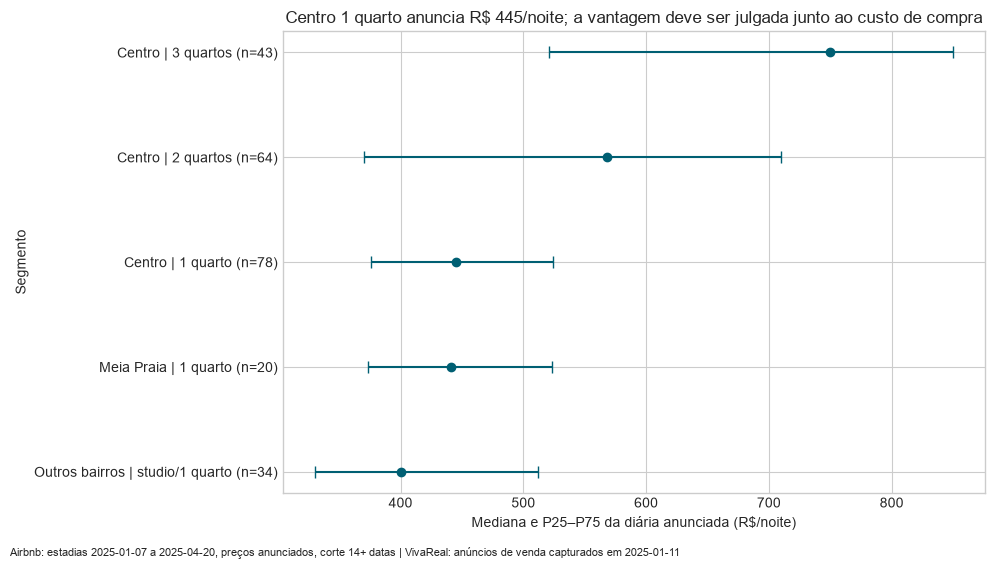

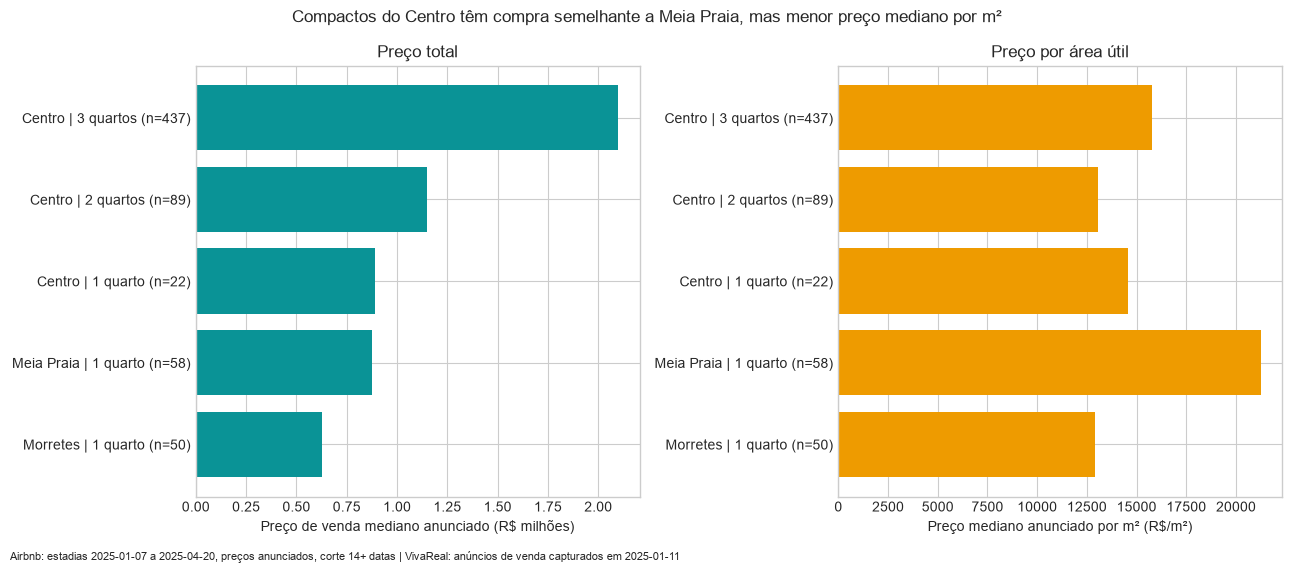

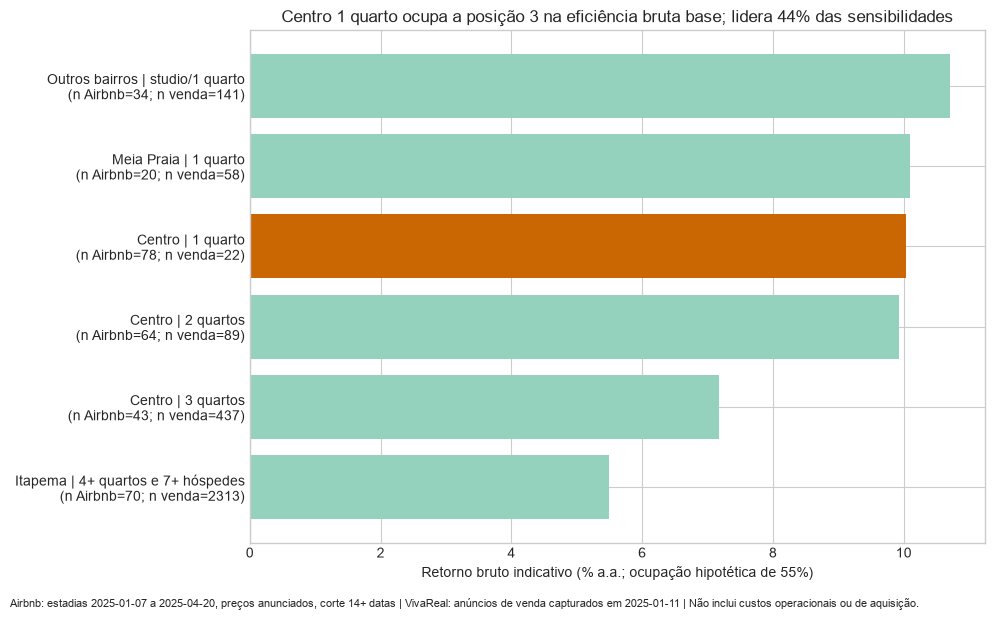

In [5]:
def caminho_saida(nome):
    destino = (SAIDAS / nome).resolve()
    assert destino.parent == SAIDAS.resolve()
    return destino


def salvar_figura(nome):
    plt.tight_layout()
    plt.savefig(caminho_saida(nome), dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()


rodape = (
    f'Airbnb: estadias {PERIODO_AIRBNB}, preços anunciados, corte 14+ datas | '
    f'VivaReal: anúncios de venda capturados em {DATA_VIVAREAL}'
)

plot_a = comparacao_tese_airbnb.loc[
    comparacao_tese_airbnb['segmento'].isin(['centro_1q', 'meiapraia_1q', 'outros_compactos', 'centro_2q', 'centro_3q'])
].sort_values('diaria_mediana_anunciada')
fig, ax = plt.subplots(figsize=(10, 5.5))
xerr = np.vstack([
    plot_a['diaria_mediana_anunciada'] - plot_a['diaria_p25_anunciada'],
    plot_a['diaria_p75_anunciada'] - plot_a['diaria_mediana_anunciada'],
])
rotulos = [f"{r.rotulo} (n={r.anuncios_airbnb})" for r in plot_a.itertuples()]
ax.errorbar(plot_a['diaria_mediana_anunciada'], rotulos, xerr=xerr, fmt='o', capsize=4, color='#005f73')
ax.set_title(
    f"Centro 1 quarto anuncia R$ {centro_1q['diaria_mediana_anunciada']:,.0f}/noite; "
    'a vantagem deve ser julgada junto ao custo de compra'
)
ax.set_xlabel('Mediana e P25–P75 da diária anunciada (R$/noite)')
ax.set_ylabel('Segmento')
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('01_diaria_tese.png')

plot_v = comparacao_tese_vivareal.loc[
    comparacao_tese_vivareal['segmento'].isin(['centro_1q', 'meiapraia_1q', 'morretes_1q', 'centro_2q', 'centro_3q'])
].sort_values('preco_venda_mediano_anunciado')
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
rotulos_v = [f"{r.rotulo} (n={r.anuncios_vivareal})" for r in plot_v.itertuples()]
axes[0].barh(rotulos_v, plot_v['preco_venda_mediano_anunciado'] / 1_000_000, color='#0a9396')
axes[0].set_xlabel('Preço de venda mediano anunciado (R$ milhões)')
axes[0].set_title('Preço total')
axes[1].barh(rotulos_v, plot_v['preco_m2_mediano_anunciado'], color='#ee9b00')
axes[1].set_xlabel('Preço mediano anunciado por m² (R$/m²)')
axes[1].set_title('Preço por área útil')
fig.suptitle('Compactos do Centro têm compra semelhante a Meia Praia, mas menor preço mediano por m²')
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('02_compra_tese.png')

plot_r = base_ranqueavel.sort_values('retorno_bruto_indicativo_base_percentual')
cores = ['#ca6702' if s == 'centro_1q' else '#94d2bd' for s in plot_r['segmento']]
fig, ax = plt.subplots(figsize=(10, 6))
rotulos_r = [f"{r.rotulo}\n(n Airbnb={r.anuncios_airbnb}; n venda={r.anuncios_vivareal})" for r in plot_r.itertuples()]
ax.barh(rotulos_r, plot_r['retorno_bruto_indicativo_base_percentual'], color=cores)
ax.set_xlabel('Retorno bruto indicativo (% a.a.; ocupação hipotética de 55%)')
ax.set_title(
    f"Centro 1 quarto ocupa a posição {int(centro_1q['ranking_base'])} na eficiência bruta base; "
    f"lidera {percentual_lideranca_centro:.0f}% das sensibilidades"
)
fig.text(0.01, -0.02, rodape + ' | Não inclui custos operacionais ou de aquisição.', fontsize=8)
salvar_figura('03_retorno_indicativo_tese.png')

In [6]:
comparacao_tese_airbnb.to_csv(caminho_saida('comparacao_tese_airbnb.csv'), index=False, encoding='utf-8')
comparacao_tese_vivareal.to_csv(caminho_saida('comparacao_tese_vivareal.csv'), index=False, encoding='utf-8')
sensibilidade_tese.to_csv(caminho_saida('sensibilidade_tese.csv'), index=False, encoding='utf-8')

melhor_base = base_ranqueavel.sort_values('ranking_base').iloc[0]
veredito_texto = f'''# Veredito da tese de compactos no Centro

## Veredito: **{veredito.upper()}**

{motivo_veredito}

## O que pôde ser testado

- Definição: compacto residencial = apartamento com studio ou 1 quarto.
- Centro, 1 quarto: {int(centro_1q['anuncios_airbnb'])} anúncios Airbnb elegíveis e {int(centro_1q['anuncios_vivareal'])} anúncios de venda comparáveis.
- Studios no Centro: {studios_centro_airbnb} no Airbnb elegível e {studios_centro_viva} no VivaReal residencial. O componente studio é **inconclusivo**.
- Airbnb cobre estadias entre {PERIODO_AIRBNB}; VivaReal foi capturado em {DATA_VIVAREAL}.

## Evidência favorável

- Centro 1 quarto tem diária mediana anunciada de R$ {centro_1q['diaria_mediana_anunciada']:,.0f}/noite.
- Seu retorno bruto indicativo base é {centro_1q['retorno_bruto_indicativo_base_percentual']:.2f}% a.a., acima de Centro 2 quartos ({centro_2q['retorno_bruto_indicativo_base_percentual']:.2f}%) e Centro 3 quartos ({centro_3q['retorno_bruto_indicativo_base_percentual']:.2f}%).

## Evidência contrária

- Meia Praia 1 quarto apresenta retorno bruto indicativo base de {meia_1q['retorno_bruto_indicativo_base_percentual']:.2f}% a.a., contra {centro_1q['retorno_bruto_indicativo_base_percentual']:.2f}% no Centro.
- O Centro fica em {int(centro_1q['ranking_base'])}º lugar entre os segmentos com amostra suficiente; o líder base é **{melhor_base['rotulo']}**, com {melhor_base['retorno_bruto_indicativo_base_percentual']:.2f}% a.a.
- Centro 1 quarto lidera {percentual_lideranca_centro:.1f}% da grade de sensibilidades. A vantagem não é dominante.

## Limites

- Diária e venda são preços anunciados, não valores realizados.
- Não há ocupação observada; 40%, 55% e 70% são hipóteses.
- Airbnb e VivaReal são amostras independentes agregadas por bairro/tipologia/quartos; não existe join entre imóveis.
- O retorno desta etapa é bruto e não inclui ITBI, cartório, condomínio, IPTU, operação, mobília ou reforma.
- A ausência de studios impede generalizar o resultado de 1 quarto para toda a categoria compacta.

A Etapa 5 aplicará custos, selecionará uma recomendação e verificará se a conclusão muda no retorno líquido.
'''
caminho_saida('veredito_tese.md').write_text(veredito_texto, encoding='utf-8')

hashes_depois = {p.name: sha256(p) for p in DADOS.glob('*.csv')}
assert hashes_depois == hashes_antes == HASHES_DADOS
esperados = {
    'comparacao_tese_airbnb.csv', 'comparacao_tese_vivareal.csv', 'sensibilidade_tese.csv',
    'veredito_tese.md', '01_diaria_tese.png', '02_compra_tese.png', '03_retorno_indicativo_tese.png',
}
assert {p.name for p in SAIDAS.iterdir()} == esperados
assert int(comparacao_tese_airbnb.loc[comparacao_tese_airbnb['segmento'].eq('centro_studio'), 'anuncios_airbnb'].iloc[0]) == 0
assert int(comparacao_tese_vivareal.loc[comparacao_tese_vivareal['segmento'].eq('centro_studio'), 'anuncios_vivareal'].iloc[0]) == 0
assert sensibilidade_tese.loc[sensibilidade_tese['ranking_no_cenario'].notna(), 'comparavel_ranqueavel'].all()
display(Markdown(veredito_texto))

# Veredito da tese de compactos no Centro

## Veredito: **REFUTADA**

O componente testável de 1 quarto não apresenta vantagem robusta de eficiência; studios permanecem sem evidência.

## O que pôde ser testado

- Definição: compacto residencial = apartamento com studio ou 1 quarto.
- Centro, 1 quarto: 78 anúncios Airbnb elegíveis e 22 anúncios de venda comparáveis.
- Studios no Centro: 0 no Airbnb elegível e 0 no VivaReal residencial. O componente studio é **inconclusivo**.
- Airbnb cobre estadias entre 2025-01-07 a 2025-04-20; VivaReal foi capturado em 2025-01-11.

## Evidência favorável

- Centro 1 quarto tem diária mediana anunciada de R$ 445/noite.
- Seu retorno bruto indicativo base é 10.04% a.a., acima de Centro 2 quartos (9.92%) e Centro 3 quartos (7.17%).

## Evidência contrária

- Meia Praia 1 quarto apresenta retorno bruto indicativo base de 10.09% a.a., contra 10.04% no Centro.
- O Centro fica em 3º lugar entre os segmentos com amostra suficiente; o líder base é **Outros bairros | studio/1 quarto**, com 10.71% a.a.
- Centro 1 quarto lidera 44.4% da grade de sensibilidades. A vantagem não é dominante.

## Limites

- Diária e venda são preços anunciados, não valores realizados.
- Não há ocupação observada; 40%, 55% e 70% são hipóteses.
- Airbnb e VivaReal são amostras independentes agregadas por bairro/tipologia/quartos; não existe join entre imóveis.
- O retorno desta etapa é bruto e não inclui ITBI, cartório, condomínio, IPTU, operação, mobília ou reforma.
- A ausência de studios impede generalizar o resultado de 1 quarto para toda a categoria compacta.

A Etapa 5 aplicará custos, selecionará uma recomendação e verificará se a conclusão muda no retorno líquido.
